# 05 · Supervised machine learning: predicting loan default

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/05_supervised_ml.ipynb)

**Goal:** train and compare the CFA supervised algorithms (penalized regression, logistic regression, KNN,
SVM, CART, random forest, boosting) with proper train/test splits, cross-validation and evaluation metrics.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

cr = pd.read_csv(DATA + "credit_default.csv")
X = pd.get_dummies(cr.drop(columns="default"), columns=["purpose"], drop_first=True, dtype=float)
y = cr["default"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
print(X_train.shape, X_test.shape, "| default rate:", round(y.mean(), 3))

(600, 9) (200, 9) | default rate: 0.206


## 1. Penalized regression (LASSO) on the factor data
We add 10 pure-noise features. LASSO should set most of them to exactly zero.

In [3]:
fr = pd.read_csv(DATA + "factor_returns.csv")
feats = fr[["mkt_excess", "smb", "hml", "mom"]].copy()
rng = np.random.default_rng(3)
for i in range(10):
    feats[f"noise_{i}"] = rng.normal(size=len(fr))
lasso = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=0)).fit(feats, fr["fund_excess"])
coefs = pd.Series(lasso[-1].coef_, index=feats.columns)
print("lambda chosen by CV:", round(lasso[-1].alpha_, 4)); print(coefs.round(3))

lambda chosen by CV: 0.1585
mkt_excess    3.232
smb           0.947
hml           0.857
mom          -0.000
noise_0       0.000
noise_1      -0.211
noise_2      -0.066
noise_3       0.000
noise_4       0.000
noise_5       0.000
noise_6      -0.093
noise_7       0.000
noise_8      -0.000
noise_9      -0.000
dtype: float64


## 2. Train several classifiers and compare test AUC
Scaling matters for distance- and margin-based models (KNN, SVM), so they go in a pipeline.

In [4]:
models = {
    "Logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN (k=15)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
    "SVM (RBF)": make_pipeline(StandardScaler(), CalibratedClassifierCV(SVC(random_state=0), ensemble=False)),   # calibrated to give probabilities
    "CART (depth 4)": DecisionTreeClassifier(max_depth=4, random_state=0),
    "Random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0),
    "Gradient boosting": GradientBoostingClassifier(random_state=0),
}
rows = []
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    p = mdl.predict_proba(X_test)[:, 1]
    cv = cross_val_score(mdl, X_train, y_train, cv=5, scoring="roc_auc").mean()
    rows.append([name, roc_auc_score(y_train, mdl.predict_proba(X_train)[:, 1]), cv, roc_auc_score(y_test, p)])
pd.DataFrame(rows, columns=["model", "train AUC", "5-fold CV AUC", "test AUC"]).set_index("model").round(3)

,train AUC,5-fold CV AUC,test AUC
model,,,
Logistic,0.838,0.831,0.837
KNN (k=15),0.815,0.703,0.741
SVM (RBF),0.892,0.765,0.737
CART (depth 4),0.820,0.693,0.616
Random forest,0.975,0.783,0.785
Gradient boosting,0.982,0.776,0.780


A big gap between **train** and **test** AUC is overfitting (variance error).

## 3. Overfitting in one picture: tree depth vs accuracy

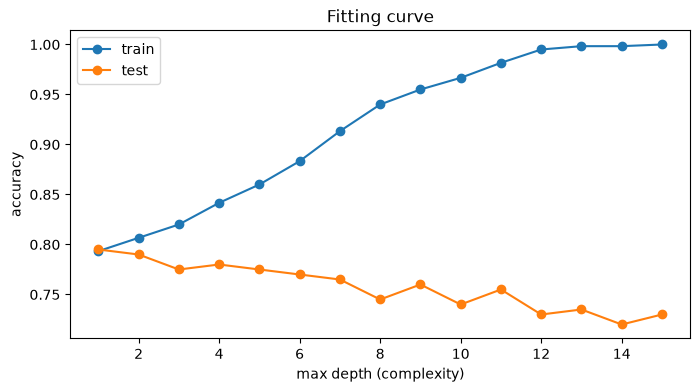

In [5]:
depths = range(1, 16); tr, te = [], []
for dpt in depths:
    t = DecisionTreeClassifier(max_depth=dpt, random_state=0).fit(X_train, y_train)
    tr.append(t.score(X_train, y_train)); te.append(t.score(X_test, y_test))
plt.plot(depths, tr, "o-", label="train"); plt.plot(depths, te, "o-", label="test")
plt.xlabel("max depth (complexity)"); plt.ylabel("accuracy"); plt.legend(); plt.title("Fitting curve"); plt.show()

## 4. Read a decision tree

In [6]:
print(export_text(DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train), feature_names=list(X.columns)))

|--- fico <= 652.50
|   |--- loan_to_value <= 95.65
|   |   |--- fico <= 604.50
|   |   |   |--- class: 1
|   |   |--- fico >  604.50
|   |   |   |--- class: 0
|   |--- loan_to_value >  95.65
|   |   |--- debt_to_income <= 34.95
|   |   |   |--- class: 1
|   |   |--- debt_to_income >  34.95
|   |   |   |--- class: 1
|--- fico >  652.50
|   |--- debt_to_income <= 38.55
|   |   |--- loan_to_value <= 104.15
|   |   |   |--- class: 0
|   |   |--- loan_to_value >  104.15
|   |   |   |--- class: 1
|   |--- debt_to_income >  38.55
|   |   |--- fico <= 694.50
|   |   |   |--- class: 0
|   |   |--- fico >  694.50
|   |   |   |--- class: 0



## 5. Which features matter? (random forest importance)

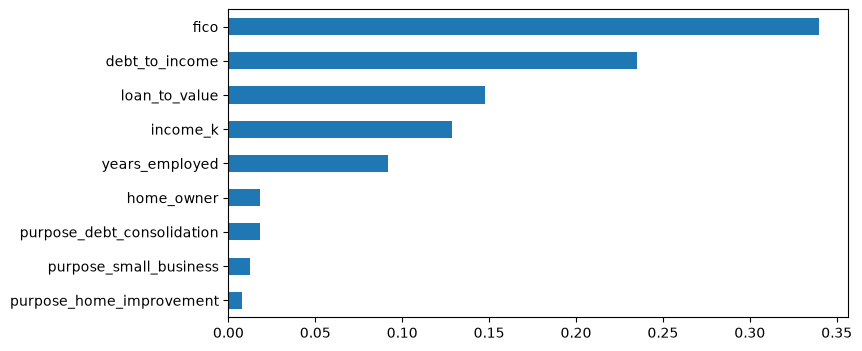

In [7]:
pd.Series(models["Random forest"].feature_importances_, index=X.columns).sort_values().plot.barh(); plt.show()

## 6. Confusion matrix, precision, recall, F1 for the logistic model

In [8]:
lg = models["Logistic"]
pred = lg.predict(X_test)   # threshold 0.5
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
print(f"TP={tp} FP={fp} FN={fn} TN={tn}")
print(f"precision={tp/(tp+fp):.3f} recall={tp/(tp+fn):.3f} accuracy={(tp+tn)/len(y_test):.3f}")
print(classification_report(y_test, pred, digits=3))

TP=17 FP=10 FN=24 TN=149
precision=0.630 recall=0.415 accuracy=0.830
              precision    recall  f1-score   support

           0      0.861     0.937     0.898       159
           1      0.630     0.415     0.500        41

    accuracy                          0.830       200
   macro avg      0.745     0.676     0.699       200
weighted avg      0.814     0.830     0.816       200



## 7. ROC curve and choosing a threshold

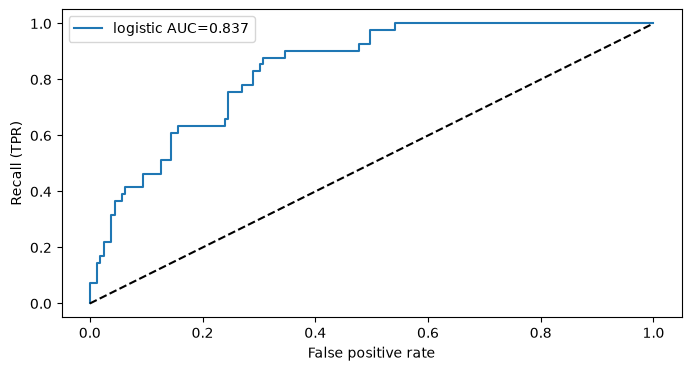

threshold 0.2: precision 0.43, recall 0.73
threshold 0.35: precision 0.50, recall 0.56
threshold 0.5: precision 0.63, recall 0.41


In [9]:
p = lg.predict_proba(X_test)[:, 1]
fpr, tpr, thr = roc_curve(y_test, p)
plt.plot(fpr, tpr, label=f"logistic AUC={roc_auc_score(y_test, p):.3f}"); plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False positive rate"); plt.ylabel("Recall (TPR)"); plt.legend(); plt.show()
for th in [0.2, 0.35, 0.5]:
    pr = (p >= th).astype(int); tn, fp, fn, tp = confusion_matrix(y_test, pr).ravel()
    print(f"threshold {th}: precision {tp/max(tp+fp,1):.2f}, recall {tp/(tp+fn):.2f}")

### Exercise 1

Try KNN (with StandardScaler in a pipeline) for k = 1, 5, 15, 51. Store the **test** accuracies in a dict `knn_test = {1: ..., 5: ..., 15: ..., 51: ...}`. Which k overfits? Which underfits?

In [10]:
# Your code here

In [11]:
check("05.1");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 05.1: not answered yet. Store your answer in `knn_test`.


### Exercise 2

Fit KNN with k = 15 **without** the StandardScaler and store its test AUC in `auc_unscaled`. Why does it drop?

<details><summary>Hint</summary>

Look at the scale of `income_k` vs `fico` vs `home_owner`.

</details>

In [12]:
# Your code here

In [13]:
check("05.2");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 05.2: not answered yet. Store your answer in `auc_unscaled`.


### Exercise 3

The bank says missing a default costs 5× more than a false alarm. Try thresholds `np.arange(0.05, 0.95, 0.05)` for the logistic model and store the one that minimises `5*FN + FP` on the test set in `best_threshold`.

In [14]:
# Your code here

In [15]:
check("05.3");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 05.3: not answered yet. Store your answer in `best_threshold`.


---
## Solutions

In [16]:
knn_test = {}
for k in [1, 5, 15, 51]:
    m = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)).fit(X_train, y_train)
    knn_test[k] = m.score(X_test, y_test)
    print(f"1) k={k:>2}: train {m.score(X_train, y_train):.3f}  test {knn_test[k]:.3f}")
raw = KNeighborsClassifier(n_neighbors=15).fit(X_train, y_train)
auc_unscaled = roc_auc_score(y_test, raw.predict_proba(X_test)[:, 1])
print("2) unscaled KNN test AUC:", round(auc_unscaled, 3), "→ fico/income dominate the distance")
costs = {th: 5 * ((p < th) & (y_test == 1)).sum() + ((p >= th) & (y_test == 0)).sum() for th in np.arange(0.05, 0.95, 0.05)}
best_threshold = min(costs, key=costs.get); print(f"3) best threshold ≈ {best_threshold:.2f}, cost {costs[best_threshold]}")
check_all("05")

1) k= 1: train 1.000  test 0.715
1) k= 5: train 0.847  test 0.820
1) k=15: train 0.815  test 0.800


1) k=51: train 0.793  test 0.795
2) unscaled KNN test AUC: 0.796 → fico/income dominate the distance
3) best threshold ≈ 0.15, cost 79
✅ Exercise 05.1: correct.
✅ Exercise 05.2: correct.
✅ Exercise 05.3: correct.

3 of 3 exercises correct.
